In [1]:
import yaml
import numpy as np
import matplotlib.pyplot as plt
from sse_core.compiler.parser import SSEParser
from sse_core.compiler.builder import SSECompiler
from sse_core.solvers.gillespie import GillespieSolver
from sse_core.solvers.export import TelemetryExporter

In [2]:
biased_pbit_yaml_str = """
schema_version: "1.0.0"
simulation:
  solver: "gillespie"
  t_finish: 1.0e-5
  v_th: 0.026
  seed: 42
nodes:
  free:
    - {name: "node3"}
    - {name: "node4"}
  regulated:
    - name: "vdd"
      type: "constant"
      value: 0.0286
    - name: "vss"
      type: "constant"
      value: -0.0286
    - name: "vb"
      type: "constant"
      value: 0.0192  # Set to V_T
    - name: "vin"
      type: "constant"
      value: 0.0    # We will sweep this dynamically
    - name: "gnd"
      type: "constant"
      value: 0.0
components:
  # NODE 3 CAPACITORS (Gate of Inv1 + Output of Inv2)
  - type: "capacitor"
    name: "C_gate_1_p"
    terminals: ["vdd", "node3"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_gate_1_n"
    terminals: ["vss", "node3"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_out_2_p"
    terminals: ["vdd", "node3"]
    specs: {capacitance: 0.5e-18}
  - type: "capacitor"
    name: "C_out_2_n"
    terminals: ["vss", "node3"]
    specs: {capacitance: 0.5e-18}

  # NODE 4 CAPACITORS (Output of Inv1 + Gate of Inv2)
  - type: "capacitor"
    name: "C_gate_2_p"
    terminals: ["vdd", "node4"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_gate_2_n"
    terminals: ["vss", "node4"]
    specs: {capacitance: 50.0e-18}
  - type: "capacitor"
    name: "C_out_1_p"
    terminals: ["vdd", "node4"]
    specs: {capacitance: 0.5e-18}
  - type: "capacitor"
    name: "C_out_1_n"
    terminals: ["vss", "node4"]
    specs: {capacitance: 0.5e-18}

  # STAGE 1 INVERTER (Input: node3 -> Output: node4)
  - type: "p_channel_mosfet"
    name: "M_inv1_p"
    terminals: {drain: "node4", gate: "node3", source: "vdd", bulk: "vdd"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
  - type: "n_channel_mosfet"
    name: "M_inv1_n"
    terminals: {drain: "node4", gate: "node3", source: "vss", bulk: "vss"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}

  # STAGE 2 INVERTER (Input: node4 -> Output: node3)
  - type: "p_channel_mosfet"
    name: "M_inv2_p"
    terminals: {drain: "node3", gate: "node4", source: "vdd", bulk: "vdd"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
  - type: "n_channel_mosfet"
    name: "M_inv2_n"
    terminals: {drain: "node3", gate: "node4", source: "vss", bulk: "vss"}
    specs: {I0: 1.6e-7, VT: 0.0, n: 1.0}
  - type: "n_channel_mosfet"
    name: "M_bias_n"
    terminals: {drain: "node4", gate: "vin", source: "vb", bulk: "gnd"}
    specs: {I0: 1.6e-8, VT: 0.0, n: 1.0}  # I0 is 1/10th of core

  # Influences output of the second inverter (node3)
  - type: "p_channel_mosfet"
    name: "M_bias_p"
    terminals: {drain: "node3", gate: "vin", source: "vb", bulk: "gnd"}
    specs: {I0: 1.6e-8, VT: 0.0, n: 1.0}  # I0 is 1/10th of core
"""

In [ ]:


# --- 1. Unified Sweep Parameters ---
v_dd = 0.0286
v_th = 0.026

# 21 points creates perfect 0.5 * v_dd steps, guaranteeing we hit exactly +/- 3.0 v_dd
vin_values = np.linspace(-5 * v_dd, 5 * v_dd, 21) 
target_inset_biases = [-3.0, 3.0] # The exact V_in / V_dd ratios to cache for 2D plots

m_results = []
histories_for_insets = []

print("Running unified sweep, caching NESS insets, and exporting to HDF5...")

# --- 2. Single-Pass Simulation Loop ---
for i, v_in in enumerate(vin_values):
    # Dynamically update Vin and Vb in the YAML AST
    yaml_dict = yaml.safe_load(biased_pbit_yaml_str)
    for node in yaml_dict['nodes']['regulated']:
        if node['name'] == 'vin':
            node['value'] = float(v_in)
        elif node['name'] == 'vb':
            node['value'] = 0.0192  # Centered offset
            
    updated_yaml = yaml.dump(yaml_dict)
    
    assembly = SSECompiler.compile_string(updated_yaml)
    parsed_netlist = SSEParser.parse_string(updated_yaml)
    
    vr_dict = {node.name: node.value for node in parsed_netlist.nodes.regulated}
    vr = np.array([vr_dict[name] for name in assembly.regulated_names], dtype=np.float64)
    
    solver = GillespieSolver(parsed_netlist, assembly)
    q_init = np.zeros(len(assembly.free_names))
    
    # 200,000 steps balances a fast 1D sweep with highly populated 2D NESS tails
    history = solver.simulate(q_init, vr, max_steps=200000)
    
    # Export to HDF5 (Safe filename formatting for signs and decimals)
    filename = f"biased_pbit_vin_{v_in/v_dd:+.1f}vdd.h5"
    TelemetryExporter.export_to_hdf5(filename, history, assembly, v_th=v_th)
    
    # Data Processing for the Sigmoid
    v1_trace = history['potentials']['node3']
    burn_in = int(len(v1_trace) * 0.01)
    v1_steady = v1_trace[burn_in:]
    
    # Calculate time-averaged magnetization <m> (Accounting for physical polarity flip)
    m_states = -np.sign(v1_steady)
    m_mean = np.mean(m_states)
    m_results.append(m_mean)
    
    print(f"Step {i+1:02d}/{len(vin_values)}: Vin = {v_in:+.3f} V | <m> = {m_mean:+.3f} | Saved: {filename}")
    
    # Cache the specific runs needed for the 2D Insets
    current_ratio = round(v_in / v_dd, 1)
    if current_ratio in target_inset_biases:
        histories_for_insets.append((v_in, history, assembly))


Running unified sweep, caching NESS insets, and exporting to HDF5...
Step 01/21: Vin = -0.143 V | <m> = -0.997 | Saved: biased_pbit_vin_-5.0vdd.h5
Step 02/21: Vin = -0.129 V | <m> = -0.997 | Saved: biased_pbit_vin_-4.5vdd.h5
Step 03/21: Vin = -0.114 V | <m> = -0.997 | Saved: biased_pbit_vin_-4.0vdd.h5
Step 04/21: Vin = -0.100 V | <m> = -0.998 | Saved: biased_pbit_vin_-3.5vdd.h5
Step 05/21: Vin = -0.086 V | <m> = -0.995 | Saved: biased_pbit_vin_-3.0vdd.h5
Step 06/21: Vin = -0.072 V | <m> = -0.965 | Saved: biased_pbit_vin_-2.5vdd.h5
Step 07/21: Vin = -0.057 V | <m> = -0.953 | Saved: biased_pbit_vin_-2.0vdd.h5
Step 08/21: Vin = -0.043 V | <m> = -0.830 | Saved: biased_pbit_vin_-1.5vdd.h5
Step 09/21: Vin = -0.029 V | <m> = -0.392 | Saved: biased_pbit_vin_-1.0vdd.h5
Step 10/21: Vin = -0.014 V | <m> = -0.214 | Saved: biased_pbit_vin_-0.5vdd.h5
Step 11/21: Vin = +0.000 V | <m> = +0.050 | Saved: biased_pbit_vin_+0.0vdd.h5
Step 12/21: Vin = +0.014 V | <m> = -0.048 | Saved: biased_pbit_vin_+0.5vd

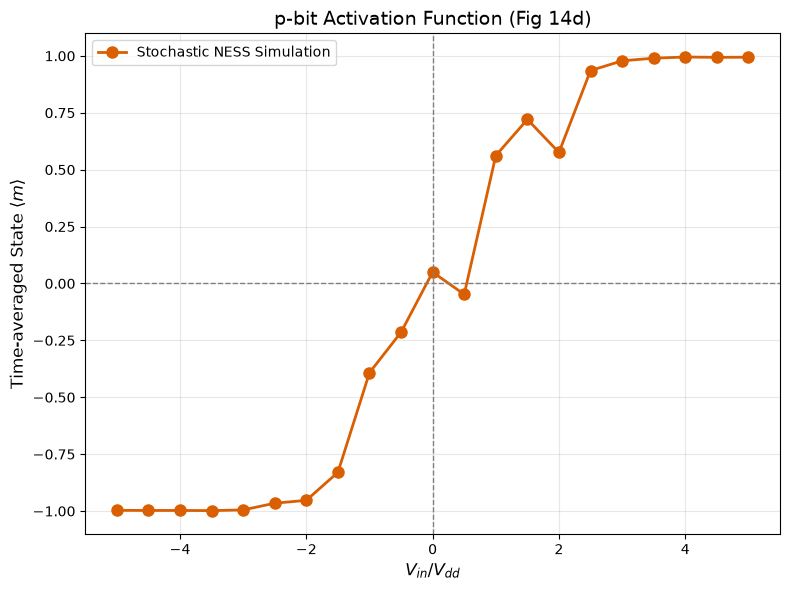

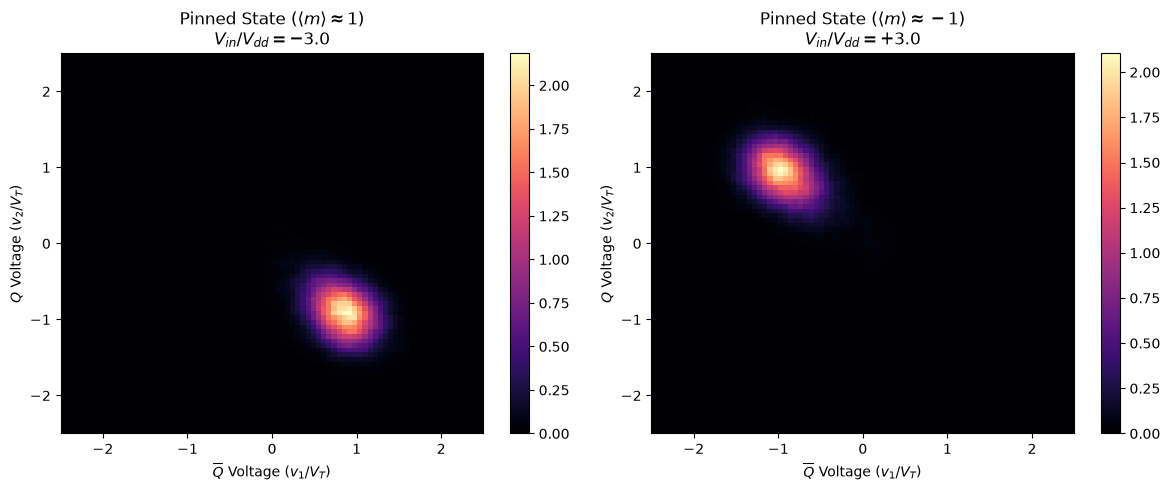

In [4]:
# --- 3. Visualization: p-bit Activation Sigmoid (Fig 14d) ---
fig_sig = plt.figure(figsize=(8, 6))
plt.plot(vin_values / v_dd, m_results, marker='o', linestyle='-', 
         color='#d95f02', linewidth=2, markersize=8, label='Stochastic NESS Simulation')

plt.axhline(0, color='gray', linestyle='--', linewidth=1)
plt.axvline(0, color='gray', linestyle='--', linewidth=1)
plt.title("p-bit Activation Function (Fig 14d)", fontsize=14)
plt.xlabel("$V_{in} / V_{dd}$", fontsize=12)
plt.ylabel("Time-averaged State $\\langle m \\rangle$", fontsize=12)
plt.ylim(-1.1, 1.1)
plt.grid(True, alpha=0.3)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


# --- 4. Visualization: 2D Pinned States ---
fig_insets, axes = plt.subplots(1, 2, figsize=(12, 5))

for i, (v_in, history, assembly) in enumerate(histories_for_insets):
    ax = axes[i]
    burn_in = int(len(history['time']) * 0.01)
    
    v1_steady = history['potentials']['node3'][burn_in:] / v_th
    v2_steady = history['potentials']['node4'][burn_in:] / v_th
    
    # Extract raw charge states for anti-aliasing bin alignment
    idx_3 = assembly.free_names.index('node3')
    idx_4 = assembly.free_names.index('node4')
    q1_steady = history['charge'][burn_in:, idx_3]
    q2_steady = history['charge'][burn_in:, idx_4]
    
    num_bins_1 = int(np.max(q1_steady) - np.min(q1_steady)) + 1
    num_bins_2 = int(np.max(q2_steady) - np.min(q2_steady)) + 1
    
    dv1 = (np.max(v1_steady) - np.min(v1_steady)) / max(1, (num_bins_1 - 1))
    dv2 = (np.max(v2_steady) - np.min(v2_steady)) / max(1, (num_bins_2 - 1))
    
    bins_v1 = np.linspace(np.min(v1_steady) - dv1/2, np.max(v1_steady) + dv1/2, num_bins_1 + 1)
    bins_v2 = np.linspace(np.min(v2_steady) - dv2/2, np.max(v2_steady) + dv2/2, num_bins_2 + 1)
    
    h, xedges, yedges, image = ax.hist2d(
        v1_steady, v2_steady, 
        bins=[bins_v1, bins_v2], 
        cmap='magma', 
        density=True
    )
    
    # Colormap blending fix
    ax.set_facecolor(image.cmap(0)) 
    
    fig_insets.colorbar(image, ax=ax)
    ax.set_xlabel('$\\overline{Q}$ Voltage ($v_1 / V_T$)')
    ax.set_ylabel('$Q$ Voltage ($v_2 / V_T$)')
    
    ax.set_xlim(-2.5, 2.5)
    ax.set_ylim(-2.5, 2.5)
    
    m_state = -np.sign(v_in)
    ax.set_title(f'Pinned State ($\\langle m \\rangle \\approx {m_state:.0f}$)\n$V_{{in}}/V_{{dd}} = {v_in/v_dd:+.1f}$')

plt.tight_layout()
plt.show()